# CCGT Gas Capex Analysis

Using Halcyon Gas Power Plant Tracker (17 July 2026)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("Halcyon_July_CCGT.csv")
df.head()

,Plant / Unit Name,State,BA Code,Announcement Date,Planned / Operating Year,Technology Type,Capacity (MW),Cost ($/kW),CapEx ($M),Actual vs. Estimated Cost,Dollar Year,Latitude,Longitude,EIA Status,EIA Plant ID
0,Trumbull Energy Center,OH,PJM,"Mar 18, 2022",2026,Combined-Cycle Gas Turbine,940.0,"1,063.83","1,000.00",-,-,31.38203,-80.8525,66918,"Clean Energy Future - Trumbull, LLC."
1,Nemadji Trail Energy Center,WI,MISO,"Jan 22, 2019",2027,Combined-Cycle Gas Turbine,550.0,"1,116.00",700.00,Estimated,2020.0,-,-,-,-
2,Orange County Advanced Power Station,TX,MISO,"Sep 16, 2021",2026,Combined-Cycle Gas Turbine,1215.0,"1,300.41","1,580.00",Estimated,2023.0,30.025251,-93.87134,66621,Entergy Texas Inc.
3,Traceview Advanced Power Station,MS,MISO,"Sep 30, 2025",2029,Combined-Cycle Gas Turbine,754.0,"1,326.26","1,000.00",Estimated,2025.0,-,-,-,-
4,Lincoln Land Energy Center,IL,MISO,"Apr 25, 2025",2030,Combined-Cycle Gas Turbine,1100.0,"1,363.64","1,500.00",-,-,39.5788,-89.57984,62022,Lincoln Land Energy Center LLC


## Data Cleaning

Drop two types of outliers before fitting anything:
- Projects with a planned/operating year **after 2032** 
- Projects with a cost **above $3000/kW** 
This leaves 28 CCGT projects to work with.

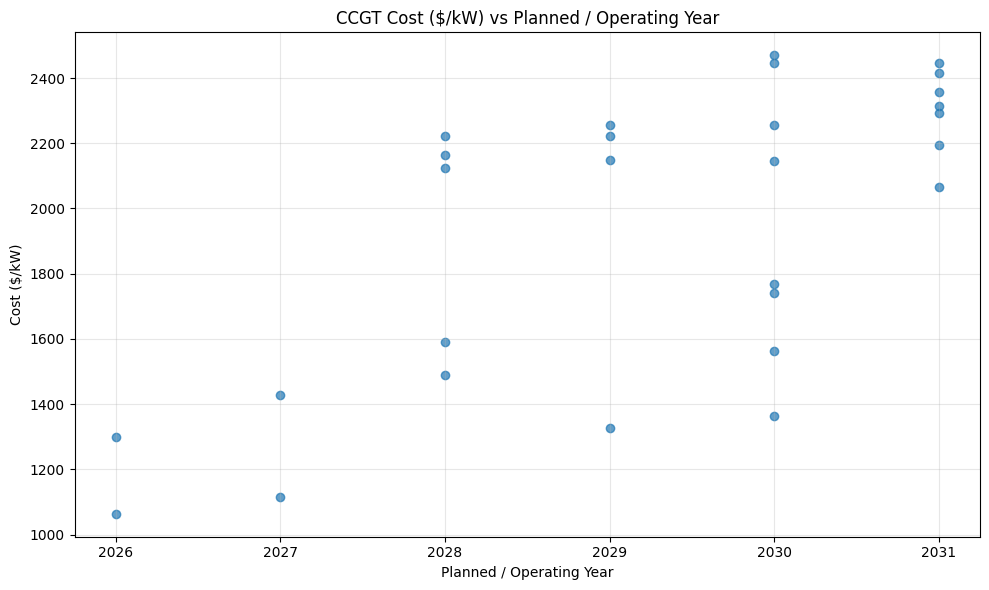

In [2]:
df["Cost ($/kW)"] = df["Cost ($/kW)"].astype(str).str.replace(",", "").astype(float)
df["Planned / Operating Year"] = pd.to_numeric(df["Planned / Operating Year"], errors="coerce")

# Clean data: drop rows with year after 2032 or cost above 3000 $/kW (outliers)
df = df[(df["Planned / Operating Year"] <= 2032) & (df["Cost ($/kW)"] <= 3000)]
df.shape

# Scatter plot: cost vs year 
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Planned / Operating Year"], df["Cost ($/kW)"], alpha=0.7)
ax.set_xlabel("Planned / Operating Year")
ax.set_ylabel("Cost ($/kW)")
ax.set_title("CCGT Cost ($/kW) vs Planned / Operating Year")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Clustering (K-Means, k=2)

Identifying 2 clusters using k-means

In [3]:
X = df[["Planned / Operating Year", "Cost ($/kW)"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Print cluster statistics
for c in sorted(df["Cluster"].unique()):
    sub = df[df["Cluster"] == c]
    print(f"\nCluster {c} — {len(sub)} plants")
    print(f"  Year    : {sub['Planned / Operating Year'].min():.0f}–{sub['Planned / Operating Year'].max():.0f}  (mean {sub['Planned / Operating Year'].mean():.1f})")
    print(f"  Cost    : ${sub['Cost ($/kW)'].min():.0f}–${sub['Cost ($/kW)'].max():.0f} /kW  (mean ${sub['Cost ($/kW)'].mean():.0f}, std ${sub['Cost ($/kW)'].std():.0f})")


Cluster 0 — 8 plants
  Year    : 2026–2030  (mean 2027.6)
  Cost    : $1064–$1592 /kW  (mean $1335, std $178)

Cluster 1 — 20 plants
  Year    : 2028–2031  (mean 2029.9)
  Cost    : $1562–$2470 /kW  (mean $2181, std $243)


K-Means (fit on standardized Year and Cost) splits the 28 plants into:
- **Cluster 0** — 8 plants, mostly earlier/cheaper projects (mean ~$1335/kW).
- **Cluster 1** — 20 plants, mostly later/pricier projects (mean ~$2181/kW).

The split is driven mainly by **cost level**, not cleanly by year — the two clusters' year ranges (2026–2030 vs 2028–2031) overlap.

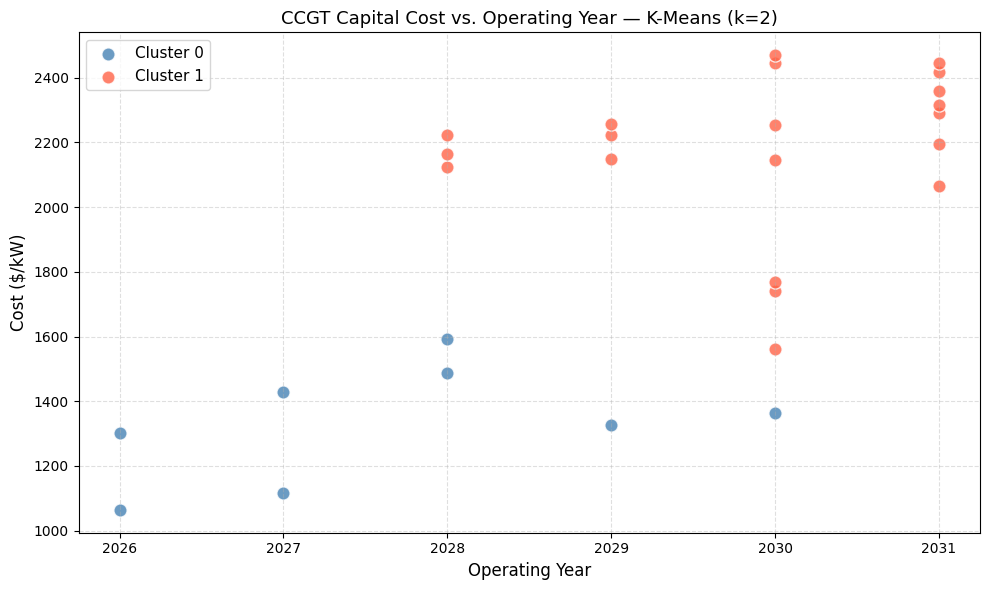

In [4]:
colors = {0: "steelblue", 1: "tomato"}
labels = {c: f"Cluster {c}" for c in sorted(df["Cluster"].unique())}

fig, ax = plt.subplots(figsize=(10, 6))

for c, grp in df.groupby("Cluster"):
    ax.scatter(grp["Planned / Operating Year"], grp["Cost ($/kW)"],
               color=colors[c], label=labels[c],
               alpha=0.8, edgecolors="white", s=90)

ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW)", fontsize=12)
ax.set_title("CCGT Capital Cost vs. Operating Year — K-Means (k=2)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## Regression per cluster


Cluster 0 — 8 plants
  Year  : 2026–2030  (mean 2027.6)
  Cost  : $1064–$1592 /kW  (mean $1335, std $178)
  Regression: slope=56.6 $/kW/yr,  R²=0.201,  p=0.265

Cluster 1 — 20 plants
  Year  : 2028–2031  (mean 2029.9)
  Cost  : $1562–$2470 /kW  (mean $2181, std $243)
  Regression: slope=36.6 $/kW/yr,  R²=0.026,  p=0.497


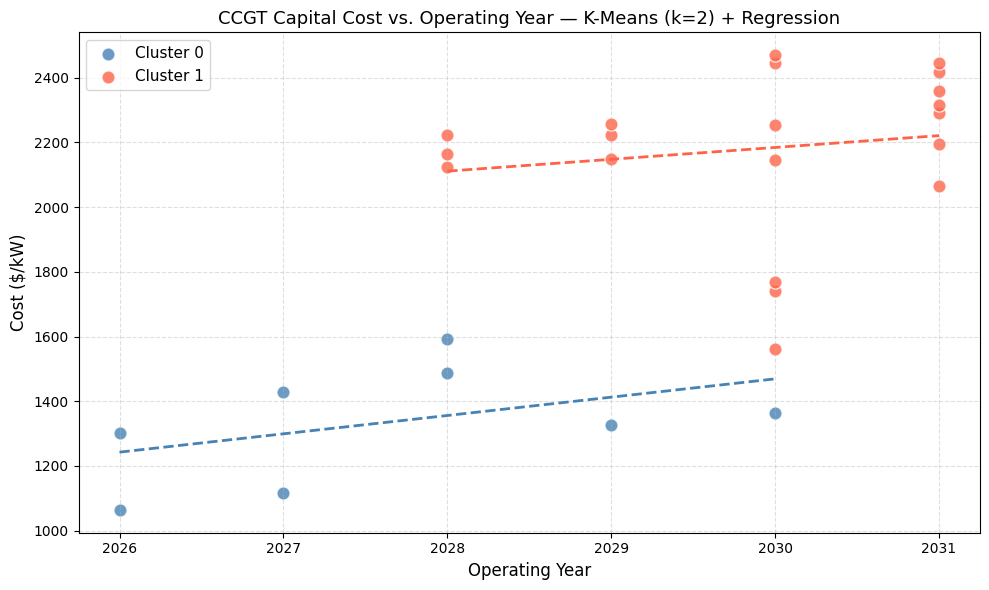

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for c, grp in df.groupby("Cluster"):
    ax.scatter(grp["Planned / Operating Year"], grp["Cost ($/kW)"],
               color=colors[c], label=labels[c],
               alpha=0.8, edgecolors="white", s=90)

    slope, intercept, r, p, _ = linregress(grp["Planned / Operating Year"], grp["Cost ($/kW)"])

    x_range = np.linspace(grp["Planned / Operating Year"].min(), grp["Planned / Operating Year"].max(), 100)
    ax.plot(x_range, intercept + slope * x_range,
            color=colors[c], linewidth=2, linestyle="--")

    print(f"\nCluster {c} — {len(grp)} plants")
    print(f"  Year  : {grp['Planned / Operating Year'].min():.0f}–{grp['Planned / Operating Year'].max():.0f}  (mean {grp['Planned / Operating Year'].mean():.1f})")
    print(f"  Cost  : ${grp['Cost ($/kW)'].min():.0f}–${grp['Cost ($/kW)'].max():.0f} /kW  (mean ${grp['Cost ($/kW)'].mean():.0f}, std ${grp['Cost ($/kW)'].std():.0f})")
    print(f"  Regression: slope={slope:.1f} $/kW/yr,  R²={r**2:.3f},  p={p:.3f}")

ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW)", fontsize=12)
ax.set_title("CCGT Capital Cost vs. Operating Year — K-Means (k=2) + Regression", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [6]:
# Extract regression statistics per cluster
stats_rows = []
for c, grp in df.groupby("Cluster"):
    slope, intercept, r, p, stderr = linregress(grp["Planned / Operating Year"], grp["Cost ($/kW)"])
    stats_rows.append({
        "Cluster": c,
        "n_plants": len(grp),
        "slope_$/kW_per_yr": slope,
        "intercept_$/kW": intercept,
        "r_squared": r**2,
        "p_value": p,
        "std_err": stderr,
    })

regression_stats = pd.DataFrame(stats_rows)
regression_stats

,Cluster,n_plants,slope_$/kW_per_yr,intercept_$/kW,r_squared,p_value,std_err
0,0,8,56.627568,-113484.859189,0.201043,0.265175,46.086107
1,1,20,36.615596,-72145.388991,0.026060,0.496545,52.760564


For each cluster we fit `Cost ($/kW) = intercept + slope * Year`: 

| Cluster | n | slope ($/kW/yr) | R² | p-value | Standard Error |
|---|---|---|---|---|---|
| 0 | 8  | +56.6 | 0.201 | 0.265 | 46.086107 |
| 1 | 20 | +36.6 | 0.026 | 0.497 | 52.760564 |

Both p-values are far above 0.05, so neither is statistically significant.. An issue might be that Cluster 0 has only 8 data points. Moreover, the standard error is nearly as large as the slope itself in both cases. 

In [7]:
# Regression values 2026-2032 (per cluster)
years = np.arange(2026, 2033)
rows = {"Year": years}
for c, grp in df.groupby("Cluster"):
    slope, intercept, _, _, _ = linregress(grp["Planned / Operating Year"], grp["Cost ($/kW)"])
    rows[f"Cluster_{c}_cost_$/kW"] = np.round(intercept + slope * years, 1)

forecast = pd.DataFrame(rows)
forecast

,Year,Cluster_0_cost_$/kW,Cluster_1_cost_$/kW
0,2026,1242.6,2037.8
1,2027,1299.2,2074.4
2,2028,1355.8,2111.0
3,2029,1412.5,2147.7
4,2030,1469.1,2184.3
5,2031,1525.7,2220.9
6,2032,1582.4,2257.5


## Regression on all data (no clustering)

Since splitting by cluster shrank each sample too much to detect a reliable trend, we also fit a single regression on **all 28 plants together**, ignoring the cluster split. This uses the full sample size and directly tests whether cost trends with year across the whole CCGT dataset.


CCGT (all data, no clustering) — 28 plants
  Year  : 2026–2031  (mean 2029.2)
  Cost  : $1064–$2470 /kW  (mean $1939, std $449)
  Regression: slope=192.8 $/kW/yr,  R²=0.447,  p=0.000


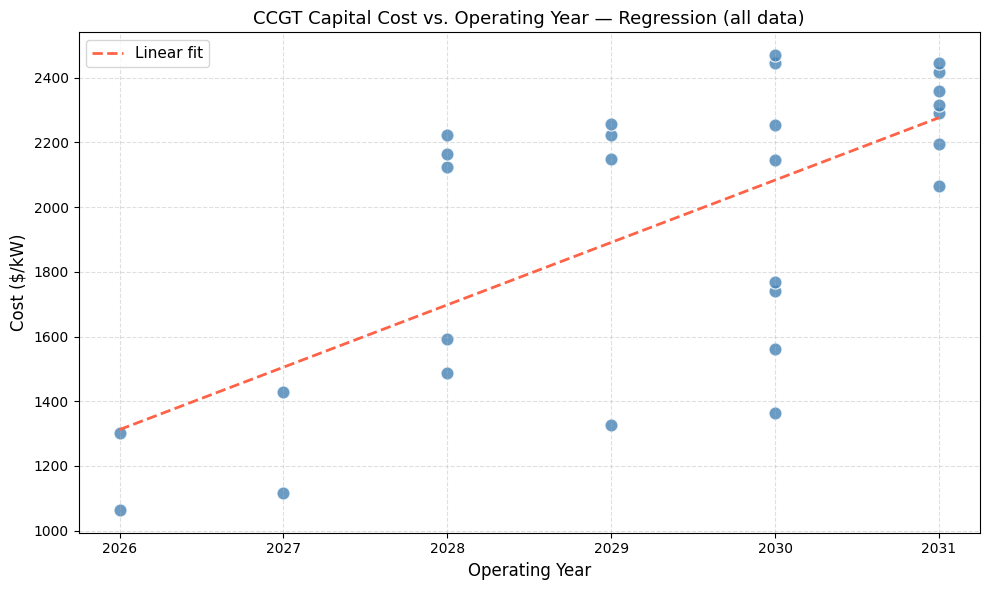

In [8]:
slope_all, intercept_all, r_all, p_all, stderr_all = linregress(df["Planned / Operating Year"], df["Cost ($/kW)"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Planned / Operating Year"], df["Cost ($/kW)"],
           color="steelblue", alpha=0.8, edgecolors="white", s=90)

x_range = np.linspace(df["Planned / Operating Year"].min(), df["Planned / Operating Year"].max(), 100)
ax.plot(x_range, intercept_all + slope_all * x_range,
        color="tomato", linewidth=2, linestyle="--", label="Linear fit")

print(f"\nCCGT (all data, no clustering) — {len(df)} plants")
print(f"  Year  : {df['Planned / Operating Year'].min():.0f}–{df['Planned / Operating Year'].max():.0f}  (mean {df['Planned / Operating Year'].mean():.1f})")
print(f"  Cost  : ${df['Cost ($/kW)'].min():.0f}–${df['Cost ($/kW)'].max():.0f} /kW  (mean ${df['Cost ($/kW)'].mean():.0f}, std ${df['Cost ($/kW)'].std():.0f})")
print(f"  Regression: slope={slope_all:.1f} $/kW/yr,  R²={r_all**2:.3f},  p={p_all:.3f}")

ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW)", fontsize=12)
ax.set_title("CCGT Capital Cost vs. Operating Year — Regression (all data)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [9]:
# Extract regression statistics (all data)
regression_stats_all = pd.DataFrame([{
    "n_plants": len(df),
    "slope_$/kW_per_yr": slope_all,
    "intercept_$/kW": intercept_all,
    "r_squared": r_all**2,
    "p_value": p_all,
    "std_err": stderr_all,
}])
regression_stats_all

,n_plants,slope_$/kW_per_yr,intercept_$/kW,r_squared,p_value,std_err
0,28,192.825977,-389353.217422,0.446582,0.000102,42.097366


- **p-value = 0.0001** << 0.05, so this trend **is statistically significant**
- **std_err = 42.1** — the slope's uncertainty is much smaller relative to the slope itself (42 vs. 193) than it was for either cluster

In [10]:
# Regression forecast 2026-2032 (all data)
forecast_all = pd.DataFrame({
    "Year": years,
    "Cost_$/kW": np.round(intercept_all + slope_all * years, 1),
})
forecast_all

,Year,Cost_$/kW
0,2026,1312.2
1,2027,1505.0
2,2028,1697.9
3,2029,1890.7
4,2030,2083.5
5,2031,2276.3
6,2032,2469.2


In [11]:
# Combine per-cluster and all-data forecasts into a single CSV for reuse (e.g. gas_ATB_update.ipynb)
combined_forecast = forecast.merge(
    forecast_all.rename(columns={"Cost_$/kW": "AllData_cost_$/kW"}),
    on="Year",
)
combined_forecast.to_csv("ccgt_regression_forecast.csv", index=False)
combined_forecast

,Year,Cluster_0_cost_$/kW,Cluster_1_cost_$/kW,AllData_cost_$/kW
0,2026,1242.6,2037.8,1312.2
1,2027,1299.2,2074.4,1505.0
2,2028,1355.8,2111.0,1697.9
3,2029,1412.5,2147.7,1890.7
4,2030,1469.1,2184.3,2083.5
5,2031,1525.7,2220.9,2276.3
6,2032,1582.4,2257.5,2469.2
